# Trace + Label Sandbox

Loads `traces_labeled.pkl` — one dict per track — containing raw signals, PELT step fits, human labels, and model predictions.

**Record keys per track:**
```
exp, idx, label, predicted_label, confidence, time, lifetime_s
clathrin_raw / _fit / _step_frames / _step_sizes / _n_steps
hsc70_raw    / _fit / _step_frames / _step_sizes / _n_steps
auxilin_raw  / _fit / _step_frames / _step_sizes / _n_steps
```


In [17]:
# ── Paths (edit if needed) ────────────────────────────────────────────────
EXPORT_PKL = "../results/traces_labeled.pkl"
UNLABELED = "__unlabeled__"
# ─────────────────────────────────────────────────────────────────────────

import sys
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Ensure the project root is on sys.path so gui_labeler can be imported
_PROJECT_ROOT = (
    str(Path(__file__).resolve().parent.parent)
    if "__file__" in dir()
    else str(Path.cwd().parent)
)
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
# Use dark mode
plt.style.use("dark_background")
print("Imports OK")

Imports OK


In [18]:
# ── Load records ──────────────────────────────────────────────────────────
with open(EXPORT_PKL, "rb") as f:
    records = pickle.load(f)

print(f"Loaded {len(records)} tracks from '{EXPORT_PKL}'")
print("Keys in each record:")
for k in records[0].keys():
    v = records[0][k]
    shape = getattr(v, "shape", None) or (len(v) if hasattr(v, "__len__") else "")
    print(f"  {k:<28} {type(v).__name__}  {shape}")

Loaded 9158 tracks from '../results/traces_labeled.pkl'
Keys in each record:
  exp                          str  4
  idx                          int  
  label                        str  5
  time                         ndarray  (600,)
  lifetime_s                   float  
  clathrin_raw                 ndarray  (600,)
  clathrin_fit                 ndarray  (600,)
  clathrin_step_frames         ndarray  (5,)
  clathrin_step_sizes          ndarray  (5,)
  clathrin_n_steps             int  
  hsc70_raw                    ndarray  (600,)
  hsc70_fit                    ndarray  (600,)
  hsc70_step_frames            ndarray  (4,)
  hsc70_step_sizes             ndarray  (4,)
  hsc70_n_steps                int  
  auxilin_raw                  ndarray  (600,)
  auxilin_fit                  ndarray  (600,)
  auxilin_step_frames          ndarray  (8,)
  auxilin_step_sizes           ndarray  (8,)
  auxilin_n_steps              int  
  predicted_label              str  5
  confidence           

In [19]:
# ── Build a summary DataFrame for convenient filtering / grouping ──────────
meta = pd.DataFrame(
    [
        {
            "exp": r["exp"],
            "idx": r["idx"],
            "label": r["label"],
            "predicted_label": r.get("predicted_label", UNLABELED),
            "confidence": r.get("confidence", float("nan")),
            "lifetime_s": r["lifetime_s"],
            "clathrin_n_steps": r["clathrin_n_steps"],
            "hsc70_n_steps": r["hsc70_n_steps"],
            "auxilin_n_steps": r["auxilin_n_steps"],
        }
        for r in records
    ]
)

# effective_label: prefer human label, fall back to predicted label
meta["effective_label"] = meta["label"].where(
    meta["label"] != UNLABELED, other=meta["predicted_label"]
)

# fast lookup (exp, idx) -> position in records list
record_index = {(r["exp"], r["idx"]): i for i, r in enumerate(records)}

# colour palette keyed by label
all_labels = sorted(set(meta["effective_label"].unique()) - {UNLABELED})
colors = sns.color_palette("Set2", len(all_labels))
color_map = dict(zip(all_labels, colors))

print(f"{len(meta)} tracks,  {meta['exp'].nunique()} experiments")
print("\nHuman label counts:")
print(meta["label"].value_counts().to_string())
print("\nPredicted label counts (all tracks):")
print(meta["predicted_label"].value_counts().to_string())
meta.head()

9158 tracks,  7 experiments

Human label counts:
label
__unlabeled__      8941
normal              118
hcs70                66
non_interesting      33

Predicted label counts (all tracks):
predicted_label
normal             7405
non_interesting    1176
hcs70               577


,exp,idx,label,predicted_label,confidence,lifetime_s,clathrin_n_steps,hsc70_n_steps,auxilin_n_steps,effective_label
0,Ex01,0,hcs70,hcs70,0.999874,120.114,5,4,8,hcs70
1,Ex01,1,__unlabeled__,non_interesting,0.613415,120.114,119,119,119,non_interesting
2,Ex01,2,__unlabeled__,normal,1.000000,120.114,3,5,12,normal
3,Ex01,3,__unlabeled__,normal,0.999998,120.114,4,4,5,normal
4,Ex01,4,__unlabeled__,normal,0.999882,120.114,5,6,11,normal


## Helper functions

In [20]:
CHANNELS = ["clathrin", "hsc70", "auxilin"]
CH_COLORS = {"clathrin": "magenta", "hsc70": "cyan", "auxilin": "yellow"}


def plot_trace(rec, ax=None, show_fit=True, title=None):
    """Plot raw signal + PELT step fit for one track record."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 2.5))
    t = rec["time"]
    for ch in CHANNELS:
        col = CH_COLORS[ch]
        ax.plot(t, rec[f"{ch}_raw"], lw=0.8, alpha=0.55, color=col, label=ch)
        if show_fit:
            fit = rec[f"{ch}_fit"]
            if len(fit) == len(t):
                ax.plot(t, fit, lw=1.8, color=col)
        # mark step positions with triangles
        sf = rec[f"{ch}_step_frames"]
        for frame in sf:
            if 0 <= frame < len(t):
                ax.axvline(t[frame], color=col, lw=0.7, ls="--", alpha=0.4)
    ax.set_xlabel("Time (s)", fontsize=8)
    ax.set_ylabel("Intensity (a.u.)", fontsize=8)
    if title is None:
        lbl = rec.get("label", UNLABELED)
        pred = rec.get("predicted_label", UNLABELED)
        conf = rec.get("confidence", float("nan"))
        title = (
            f"{rec['exp']} #{rec['idx']}  " f"\nlabel={lbl}  pred={pred} ({conf:.2f})  "
        )
    ax.set_title(title, fontsize=7.5)
    ax.legend(fontsize=7, loc="upper right", framealpha=0.4)
    return ax


def plot_grid(subset_records, ncols=3, figsize_per=(8, 2.5), title=None):
    """Plot a grid of traces from a list of records."""
    n = len(subset_records)
    if n == 0:
        print("No records to plot.")
        return
    nrows = max(1, (n + ncols - 1) // ncols)
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows),
        squeeze=False,
    )
    for ax, rec in zip(axes.flatten(), subset_records):
        plot_trace(rec, ax=ax)
    for ax in axes.flatten()[n:]:
        ax.set_visible(False)
    if title:
        fig.suptitle(title, y=1.01, fontsize=10, fontweight="bold")
    plt.tight_layout()
    return fig


def get_records(label, source="predicted_label", min_conf=None, n=None):
    """Return records matching a label (from 'label', 'predicted_label', or 'effective_label')."""
    mask = meta[source] == label
    if min_conf is not None:
        mask &= meta["confidence"] >= min_conf
    rows = meta[mask]
    if n is not None:
        rows = rows.head(n)
    return [records[record_index[(r.exp, r.idx)]] for _, r in rows.iterrows()]


print("Helpers defined:  plot_trace()  |  plot_grid()  |  get_records()")

Helpers defined:  plot_trace()  |  plot_grid()  |  get_records()


## 1 · Sample traces per predicted label

High-confidence examples (≥ 0.8) for every class.

── hcs70  (total n=577) ──


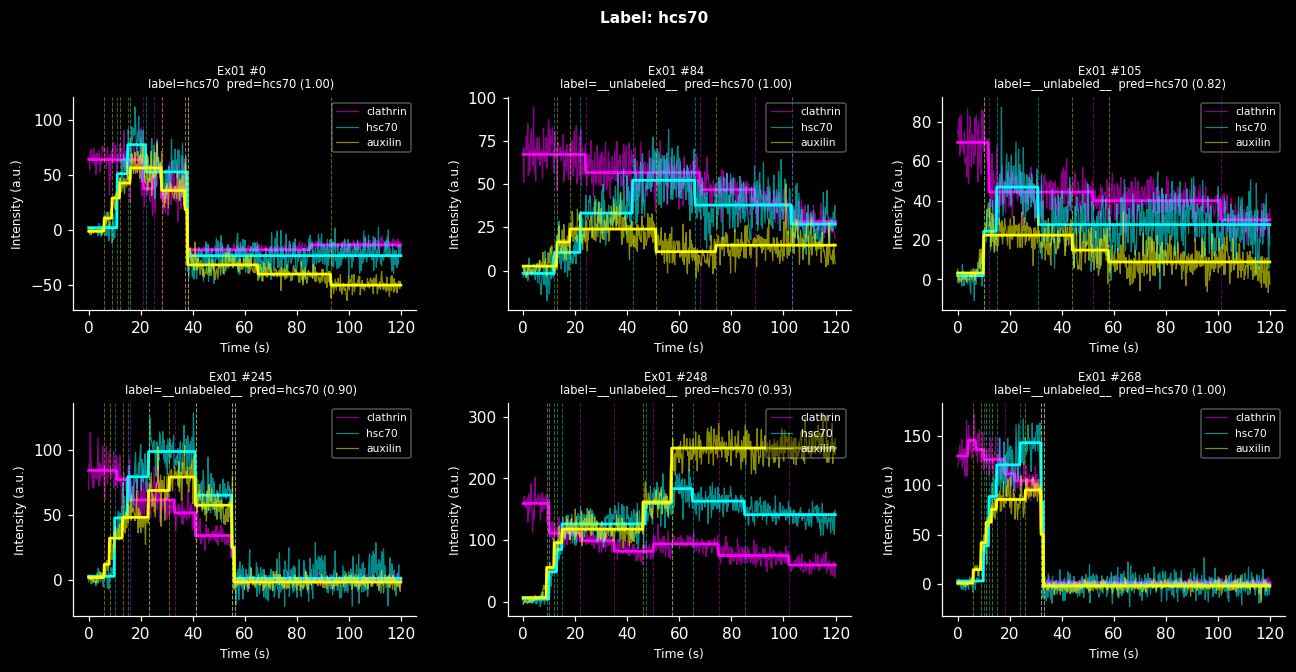

── non_interesting  (total n=1176) ──


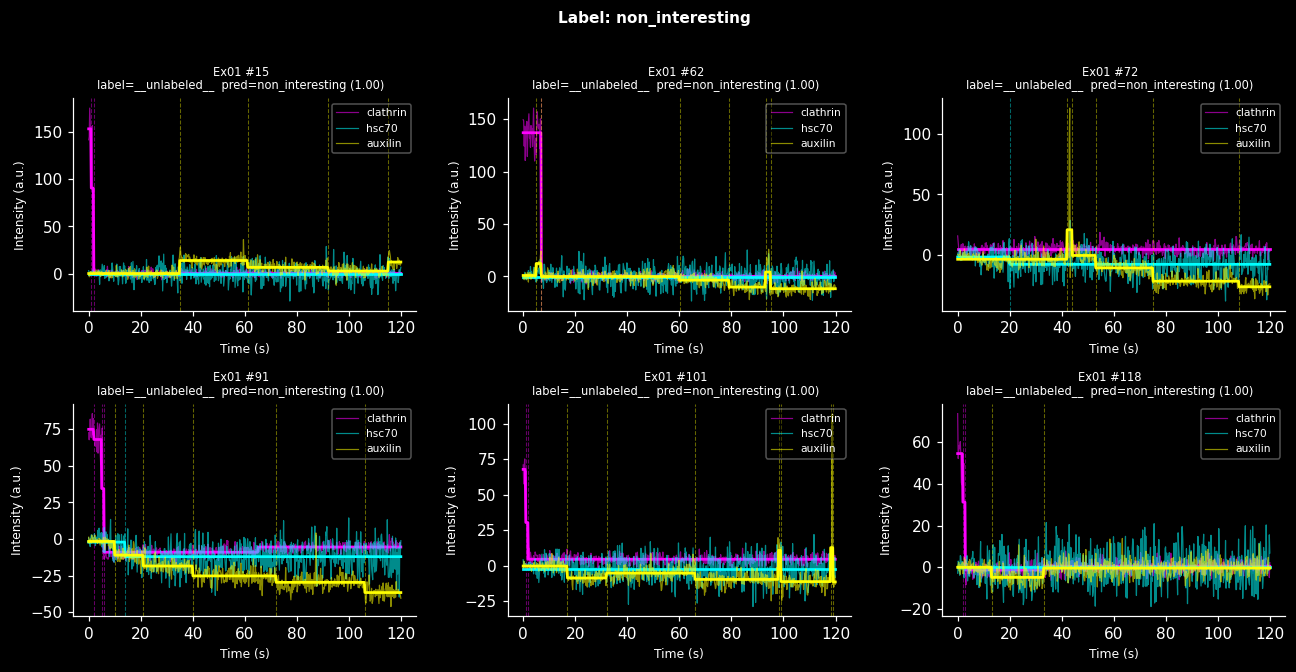

── normal  (total n=7405) ──


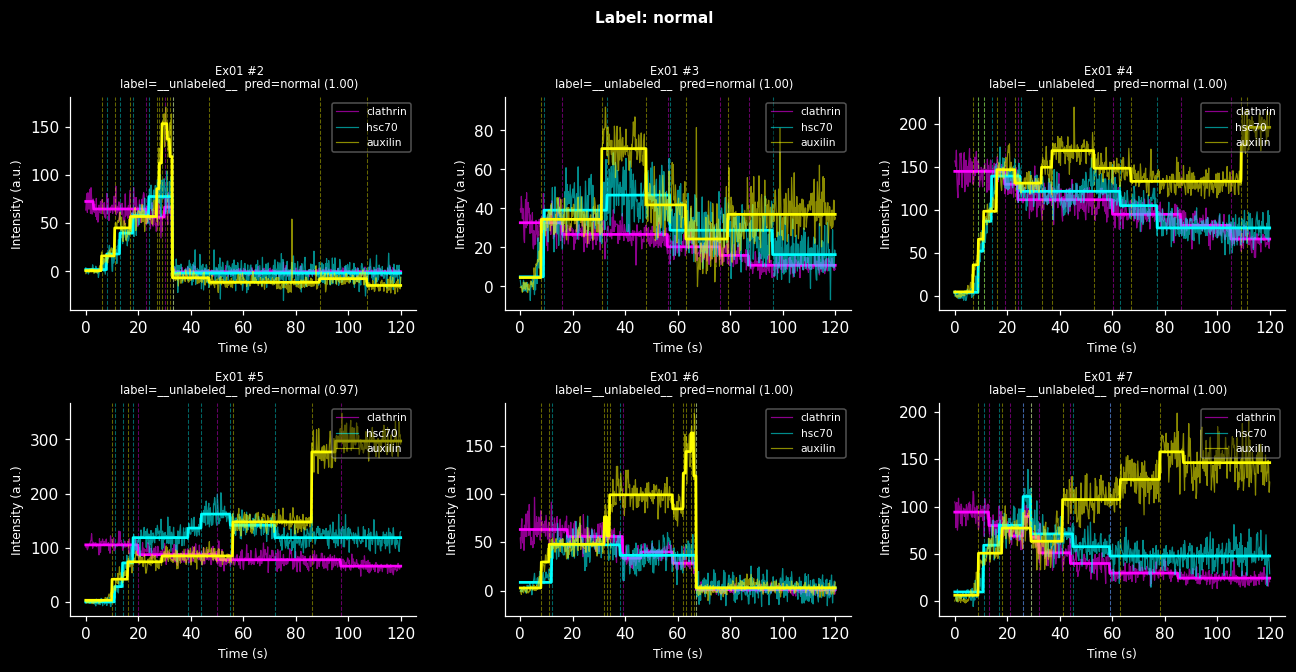

In [21]:
N_EXAMPLES = 6  # traces per label

for lbl in all_labels:
    recs = get_records(lbl, source="predicted_label", min_conf=0.8, n=N_EXAMPLES)
    if len(recs) < N_EXAMPLES:  # fall back if not enough high-conf
        recs = get_records(lbl, source="predicted_label", n=N_EXAMPLES)
    n_total = (meta["predicted_label"] == lbl).sum()
    print(f"── {lbl}  (total n={n_total}) ──")
    plot_grid(recs, ncols=3, title=f"Label: {lbl}", figsize_per=(4, 3))
    plt.show()

## 2 · Lifetime distribution per label

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── left: histogram ──
ax = axes[0]
for lbl in all_labels:
    vals = meta.loc[meta["effective_label"] == lbl, "lifetime_s"]
    ax.hist(
        vals,
        bins=40,
        alpha=0.55,
        label=f"{lbl} (n={len(vals)})",
        color=color_map[lbl],
        density=True,
    )
ax.set_xlabel("Lifetime (s)")
ax.set_ylabel("Density")
ax.set_title("Lifetime distribution per label")
ax.legend()

# ── right: CDF ──
ax = axes[1]
for lbl in all_labels:
    vals = np.sort(meta.loc[meta["effective_label"] == lbl, "lifetime_s"].dropna())
    cdf = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf, color=color_map[lbl], lw=2, label=lbl)
ax.set_xlabel("Lifetime (s)")
ax.set_ylabel("CDF")
ax.set_title("Cumulative lifetime distribution")
ax.legend()

plt.tight_layout()
plt.show()

## 3 · Confidence distribution per predicted label

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for lbl in all_labels:
    vals = meta.loc[meta["predicted_label"] == lbl, "confidence"].dropna()
    ax.hist(
        vals,
        bins=30,
        alpha=0.55,
        label=f"{lbl} (n={len(vals)})",
        color=color_map[lbl],
        density=True,
    )
ax.axvline(0.8, ls="--", color="gray", lw=1.2, label="0.8 threshold")
ax.set_xlabel("Max class probability (confidence)")
ax.set_ylabel("Density")
ax.set_title("Confidence distribution per predicted label")
ax.legend()
plt.tight_layout()
plt.show()

print("High-confidence (≥ 0.8) counts:")
print(meta.loc[meta["confidence"] >= 0.8, "predicted_label"].value_counts().to_string())

## 4 · PELT step counts per label (box plots)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, ch in zip(axes, CHANNELS):
    data = [
        meta.loc[meta["effective_label"] == lbl, f"{ch}_n_steps"].values
        for lbl in all_labels
    ]
    bparts = ax.boxplot(
        data,
        labels=all_labels,
        notch=False,
        patch_artist=True,
        widths=0.5,
    )
    for patch, lbl in zip(bparts["boxes"], all_labels):
        patch.set_facecolor((*color_map[lbl], 0.55))
    ax.set_title(f"{ch} – PELT step count")
    ax.set_ylabel("n steps")
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("PELT detected step counts per label", y=1.02)
plt.tight_layout()
plt.show()

## 5 · Per-experiment label breakdown (stacked bar)

In [ ]:
pivot = (
    meta.groupby(["exp", "effective_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=all_labels, fill_value=0)
)
pivot_frac = pivot.div(pivot.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# absolute counts
pivot.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[color_map[l] for l in all_labels],
    edgecolor="white",
    width=0.7,
)
axes[0].set_title("Track count per experiment")
axes[0].set_xlabel("")
axes[0].set_ylabel("# tracks")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="label", fontsize=8)

# fractional
pivot_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[color_map[l] for l in all_labels],
    edgecolor="white",
    width=0.7,
)
axes[1].set_title("Fraction per experiment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Fraction")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="label", fontsize=8)

plt.tight_layout()
plt.show()
print(pivot.to_string())

## 6 · Clathrin step-size distribution per label

Distribution of individual PELT-detected clathrin step sizes (positive = loss event).

In [ ]:
CHANNEL = "clathrin"  # change to "hsc70" or "auxilin" if desired

step_sizes_by_label = {}
for lbl in all_labels:
    rows = meta[meta["effective_label"] == lbl]
    sizes = np.concatenate(
        [
            records[record_index[(r.exp, r.idx)]][f"{CHANNEL}_step_sizes"]
            for _, r in rows.iterrows()
        ]
    )
    step_sizes_by_label[lbl] = sizes

fig, ax = plt.subplots(figsize=(9, 4))
for lbl in all_labels:
    vals = step_sizes_by_label[lbl]
    if len(vals) == 0:
        continue
    ax.hist(
        vals,
        bins=60,
        alpha=0.5,
        density=True,
        color=color_map[lbl],
        label=f"{lbl} (n={len(vals)} steps)",
    )
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel(f"{CHANNEL} step size (a.u.)")
ax.set_ylabel("Density")
ax.set_title(f"{CHANNEL} PELT step-size distribution per label")
ax.legend()
plt.tight_layout()
plt.show()

## 7 · Lifetime vs. clathrin step count scatter

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
for lbl in all_labels:
    sub = meta[meta["effective_label"] == lbl]
    ax.scatter(
        sub["lifetime_s"],
        sub["clathrin_n_steps"],
        alpha=0.3,
        s=12,
        color=color_map[lbl],
        label=lbl,
        rasterized=True,
    )
ax.set_xlabel("Lifetime (s)")
ax.set_ylabel("Clathrin PELT steps (n)")
ax.set_title("Lifetime vs. clathrin step count — coloured by label")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

---

## 8 · Free exploration

Use `records`, `meta`, and the helpers below freely.

```python
# Quick-access patterns:

# All records for one label with high confidence
recs = get_records("normal", source="predicted_label", min_conf=0.9)

# One specific track by experiment + index
rec = records[record_index[("Ex01", 42)]]
plot_trace(rec); plt.show()

# Filter meta and iterate
sub = meta[(meta["lifetime_s"] > 30) & (meta["effective_label"] == "hsc70_excess")]
for _, row in sub.head(6).iterrows():
    rec = records[record_index[(row.exp, row.idx)]]
    plot_trace(rec); plt.show()
```

In [ ]:
# ── Sandbox ───────────────────────────────────────────────────────────────
# Edit freely — records and meta are ready to use.

# Example: show a grid of the 6 longest tracks of a given label
TARGET = all_labels[0]  # change as needed

longest = meta[meta["effective_label"] == TARGET].nlargest(6, "lifetime_s")
recs = [records[record_index[(r.exp, r.idx)]] for _, r in longest.iterrows()]
plot_grid(recs, ncols=3, title=f"Longest tracks — {TARGET}")
plt.show()